In [75]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from data_preparation.data_processor import DataProcessor
#from models import XGBoostParams

import xgboost as xgb
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL


In [76]:
XGBoostParams =  {
    "Municipal": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 90,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Industrial": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 0.5
    },
    "Organic": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 110,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    },
    "Construction": {
        "colsample_bytree": 0.8,
        "gamma": 0,
        "learning_rate": 0.09000000000000001,
        "max_depth": 3,
        "min_child_weight": 5,
        "n_estimators": 70,
        "reg_alpha": 0,
        "reg_lambda": 1
    },
    "Commercial": {
        "colsample_bytree": 1.0,
        "gamma": 0,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 70,
        "reg_alpha": 0.5,
        "reg_lambda": 1
    }
}

In [77]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
diff_waste_dfs = {}

lags = [1,6]

for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    prep_data_company["quantity_tons"] = prep_data_company["quantity_tons"].diff() 

    diff_waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= True, interaction_terms= False)


for c in range(len(unique_waste)):
    waste = list(diff_waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(diff_waste_dfs[waste].shape)

Data shape for Municipal:
(1089, 28)
Data shape for Industrial:
(1089, 28)
Data shape for Organic:
(1089, 28)
Data shape for Construction:
(1089, 28)
Data shape for Commercial:
(1089, 28)


In [78]:
diff_waste_dfs["Municipal"]

,is_Fall,is_Spring,is_Summer,is_Winter,quantity_tons,is_weekend,is_holiday,dayofweek,quarter,month,...,annual_fourier_sin_2,annual_fourier_cos_2,annual_fourier_sin_3,annual_fourier_cos_3,annual_fourier_sin_4,annual_fourier_cos_4,weekly_fourier_sin_1,weekly_fourier_cos_1,weekly_fourier_sin_2,weekly_fourier_cos_2
date,,,,,,,,,,,,,,,,,,,,,
2022-01-08,0.0,0.0,0.0,1.0,-28.714958,1.0,0.0,5,1,1,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000
2022-01-09,0.0,0.0,0.0,1.0,-57.887192,1.0,0.0,6,1,1,...,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,7.818315e-01,0.623490,9.749279e-01,-0.222521
2022-01-10,0.0,0.0,0.0,1.0,87.551895,0.0,0.0,0,1,1,...,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,9.749279e-01,-0.222521,-4.338837e-01,-0.900969
2022-01-11,0.0,0.0,0.0,1.0,-4.451279,0.0,0.0,1,1,1,...,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,4.338837e-01,-0.900969,-7.818315e-01,0.623490
2022-01-12,0.0,0.0,0.0,1.0,-3.140831,0.0,0.0,2,1,1,...,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,-4.338837e-01,-0.900969,7.818315e-01,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,0.0,0.0,0.0,1.0,-97.968933,0.0,1.0,4,4,12,...,-0.369725,0.929141,-0.538005,0.842942,-0.687053,0.726608,-7.818315e-01,0.623490,-9.749279e-01,-0.222521
2024-12-28,0.0,0.0,0.0,1.0,-140.899521,1.0,1.0,5,4,12,...,-0.337523,0.941317,-0.493776,0.869589,-0.635432,0.772157,-4.506948e-14,1.000000,-9.013896e-14,1.000000
2024-12-29,0.0,0.0,0.0,1.0,-84.930397,1.0,0.0,6,4,12,...,-0.304921,0.952378,-0.448229,0.893919,-0.580800,0.814046,7.818315e-01,0.623490,9.749279e-01,-0.222521


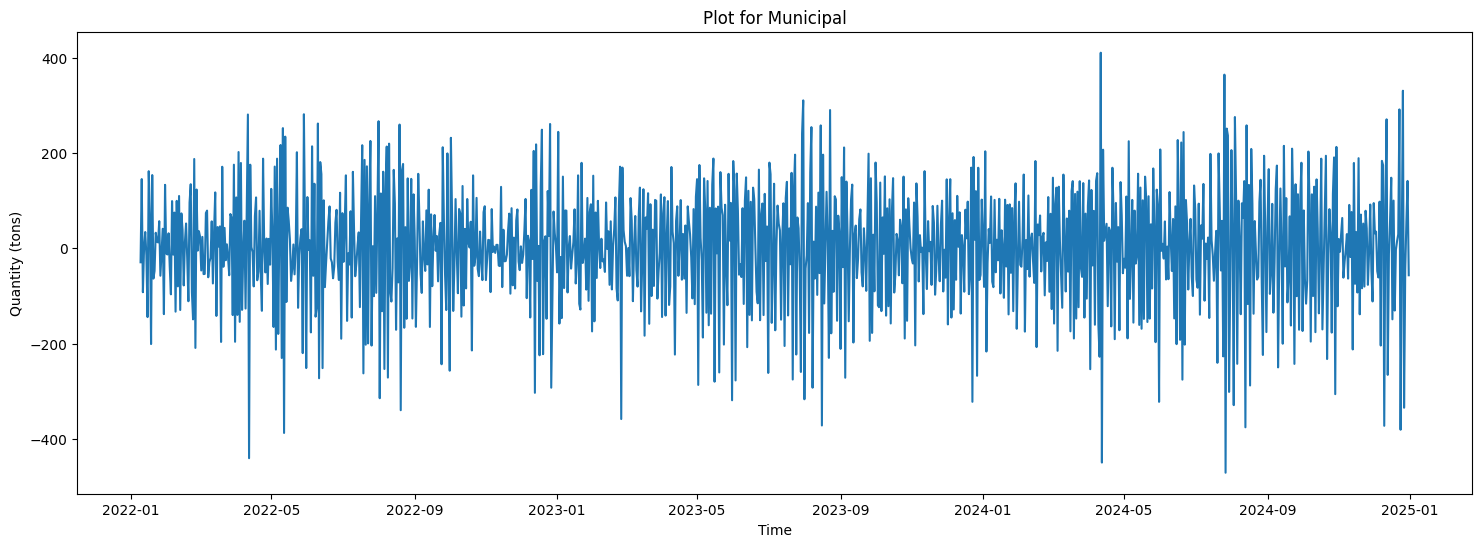

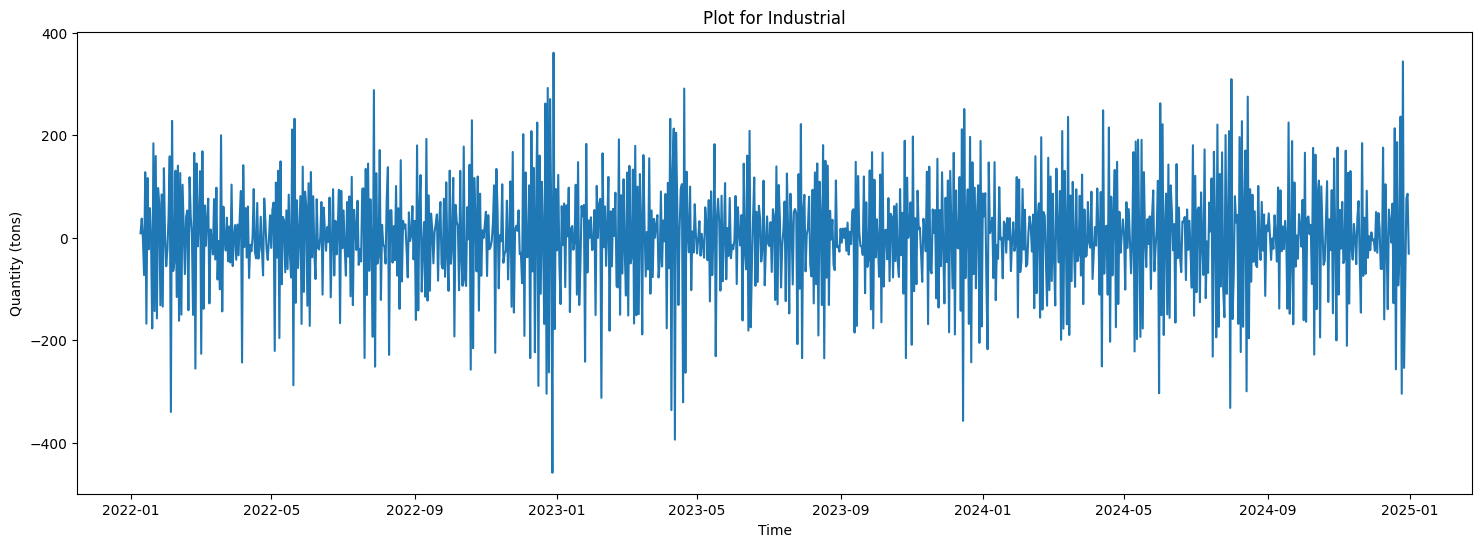

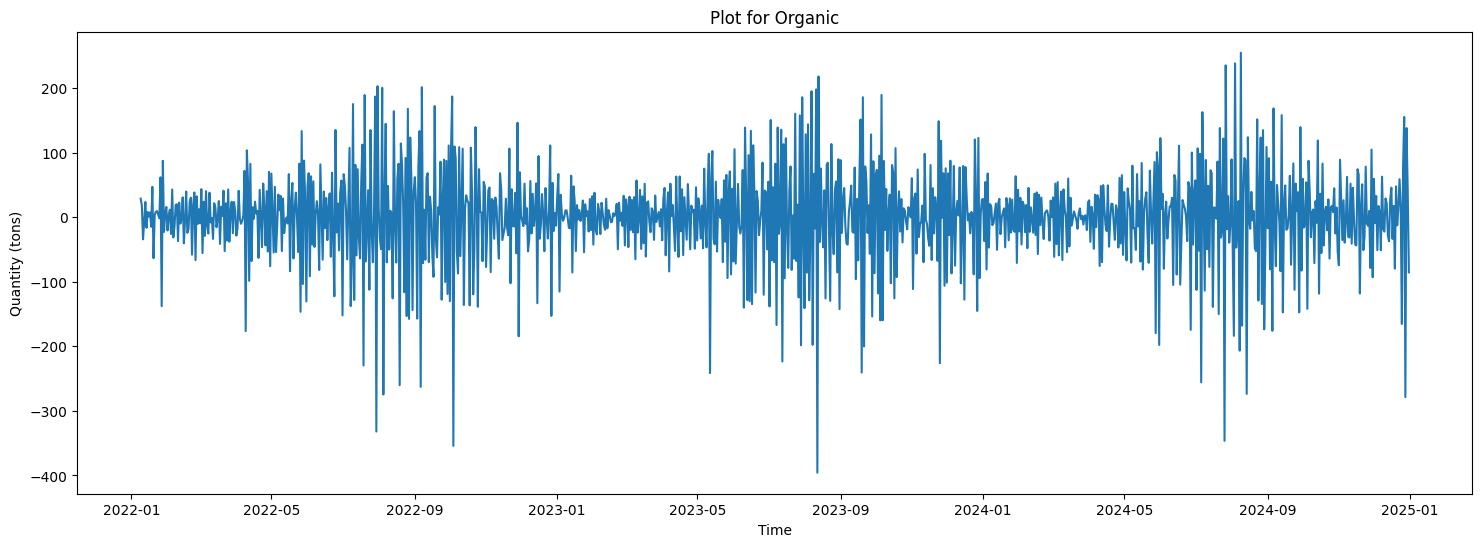

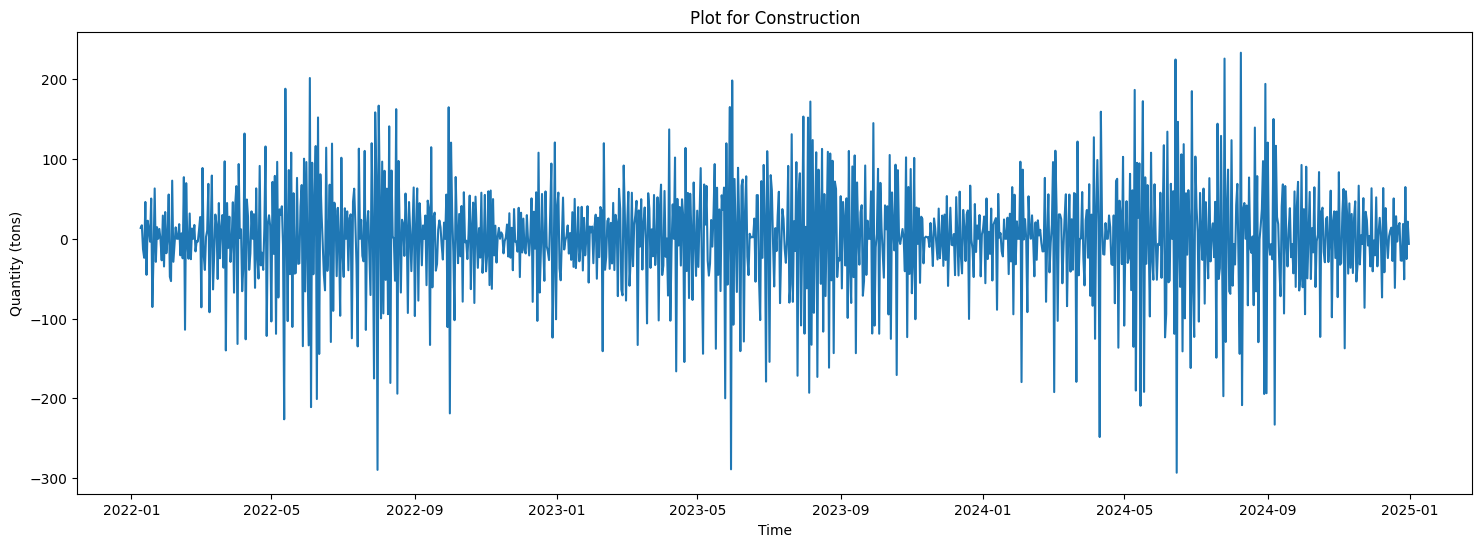

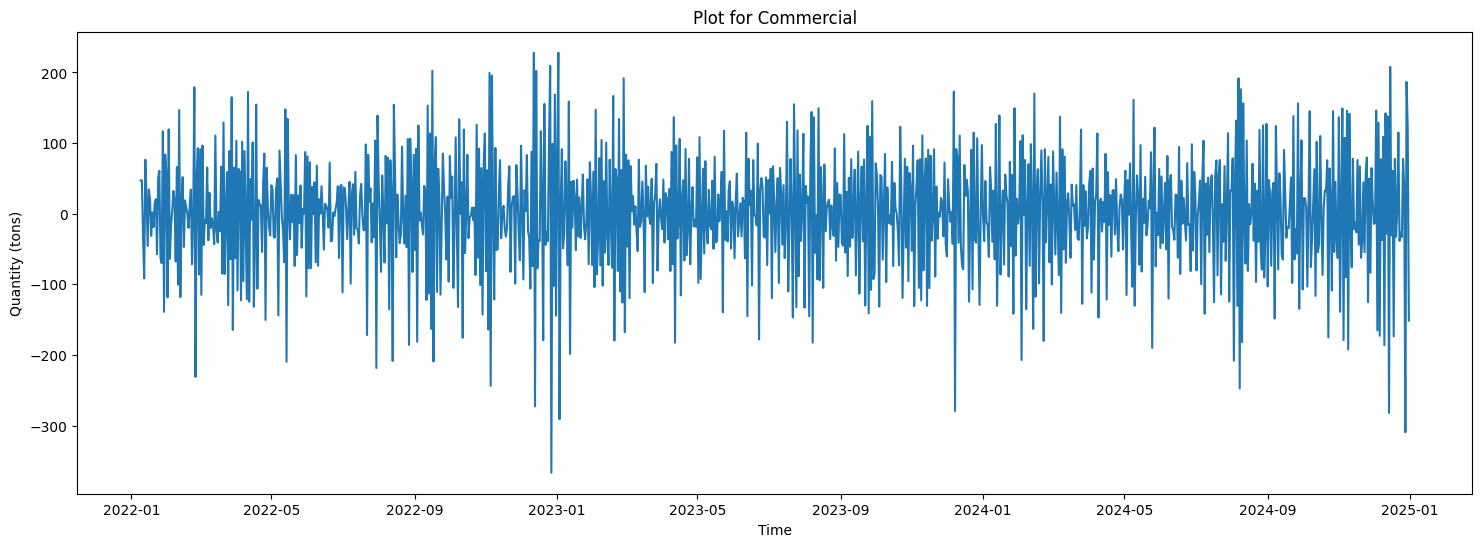

In [79]:
for waste in unique_waste:
    plt.figure(figsize=(18,6))
    # Filter out zero values
    #non_zero_data = waste_dfs[waste][waste_dfs[waste]["quantity_tons"] > 0]
    #differenced_data = non_zero_data.diff()
    differenced_data = diff_waste_dfs[waste].diff()
    plt.plot(differenced_data["quantity_tons"])
    plt.title(f"Plot for {waste}")
    plt.xlabel("Time")
    plt.ylabel("Quantity (tons)")
    plt.show()


In [80]:
from statsmodels.tsa.stattools import adfuller

# Dictionary to store results
stationarity_results = {}

for waste in unique_waste:
    ts = diff_waste_dfs[waste]["quantity_tons"].dropna()  # Ensure no NaN values
    
    # Perform ADF test
    result = adfuller(ts, autolag = "AIC")
    
    # Store results
    stationarity_results[waste] = {
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Critical Values": result[4],
        "Stationary": result[1] < 0.05  
    }
    
    print(f"Waste Type: {waste}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    print("-" * 40)

Waste Type: Municipal
ADF Statistic: -8.9098
p-value: 0.0000
Critical Values: {'1%': -3.4364934880312177, '5%': -2.8642525616723336, '10%': -2.568214266743025}
----------------------------------------
Waste Type: Industrial
ADF Statistic: -10.3388
p-value: 0.0000
Critical Values: {'1%': -3.4364992651202697, '5%': -2.8642551098431968, '10%': -2.5682156239065925}
----------------------------------------
Waste Type: Organic
ADF Statistic: -12.8363
p-value: 0.0000
Critical Values: {'1%': -3.4364819663568262, '5%': -2.864247479652846, '10%': -2.568211560046239}
----------------------------------------
Waste Type: Construction
ADF Statistic: -13.1934
p-value: 0.0000
Critical Values: {'1%': -3.4364819663568262, '5%': -2.864247479652846, '10%': -2.568211560046239}
----------------------------------------
Waste Type: Commercial
ADF Statistic: -13.1135
p-value: 0.0000
Critical Values: {'1%': -3.4364819663568262, '5%': -2.864247479652846, '10%': -2.568211560046239}
-------------------------------

<Figure size 1000x800 with 0 Axes>

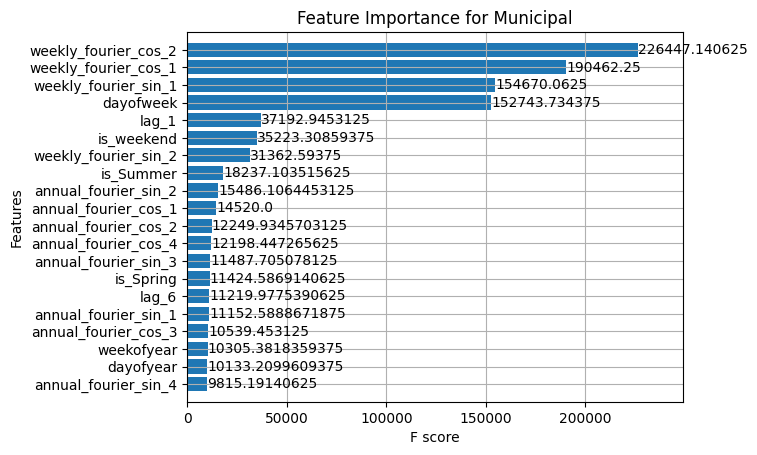

<Figure size 1000x800 with 0 Axes>

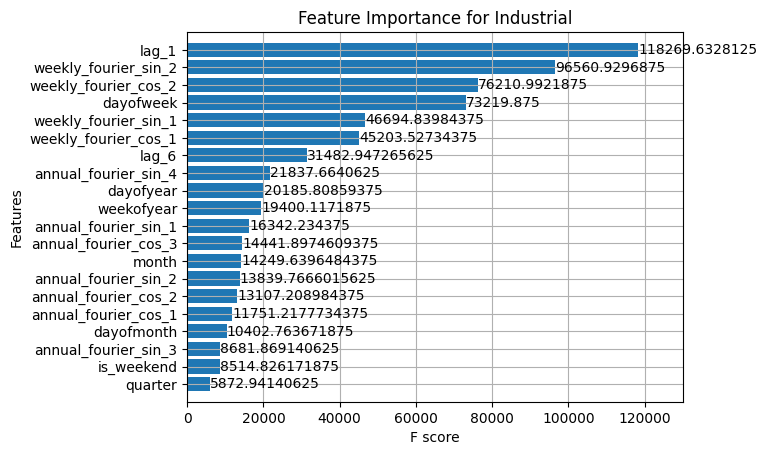

<Figure size 1000x800 with 0 Axes>

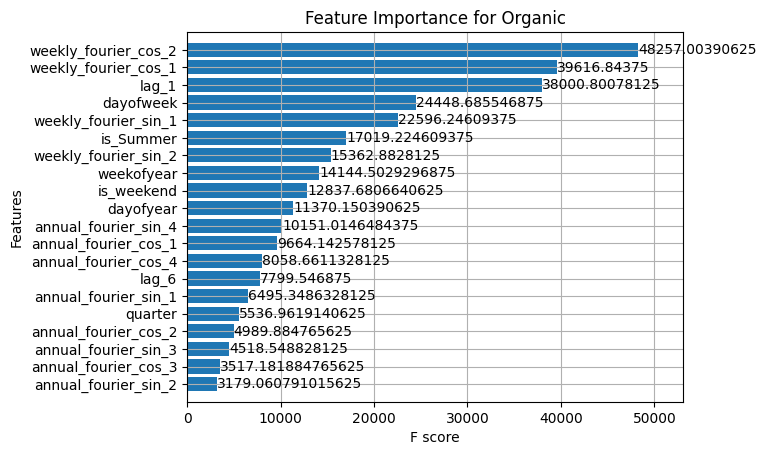

<Figure size 1000x800 with 0 Axes>

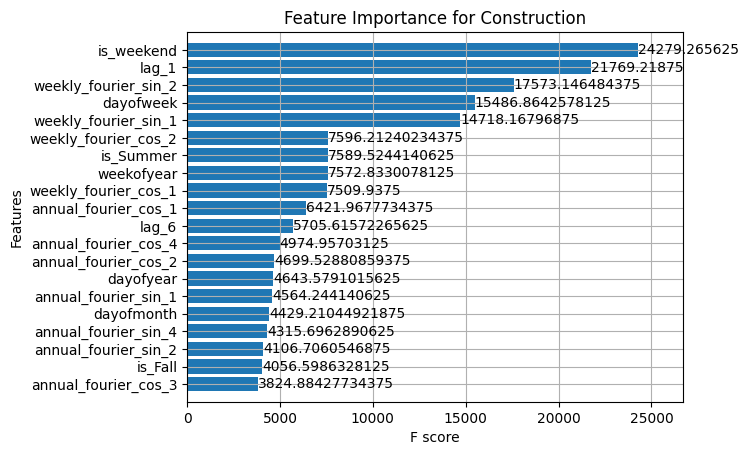

<Figure size 1000x800 with 0 Axes>

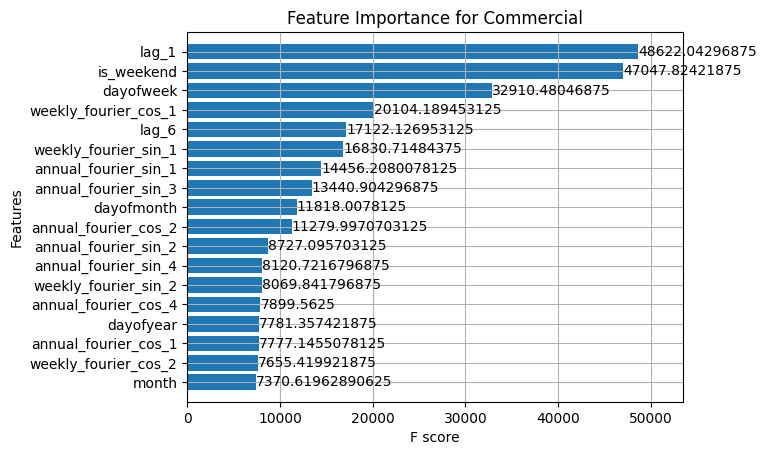

In [81]:
split_index = int(diff_waste_dfs["Municipal"].shape[0] * 0.8)


waste_quantity_preds = {}

for waste, df in diff_waste_dfs.items():

    X = df.drop(columns=['quantity_tons'])
    y = df['quantity_tons']

    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Get the best parameters for this company
    best_params = XGBoostParams[waste]
    
    # Create and train the model with best parameters
    best_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **best_params  # Unpack the parameters
    )
    
    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    waste_quantity_preds[waste] = y_pred

    # Plot feature importance
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(best_model, max_num_features=20, height=0.8, importance_type="gain")
    plt.title(f"Feature Importance for {waste}")
    plt.show()

In [82]:
from sklearn.metrics import root_mean_squared_error

total_actual = np.sum(
    [diff_waste_dfs[waste]['quantity_tons'].values[split_index:] for waste in diff_waste_dfs],
    axis=0
)


total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

print(f"RMSE:{root_mean_squared_error(total_actual, total_predicted)}")

for waste in unique_waste:
    actual = np.sum(
    [diff_waste_dfs[waste]['quantity_tons'].values[split_index:]],
    axis=0)

    predicted = waste_quantity_preds[waste]

    print(f"RMSE for {waste}: {root_mean_squared_error(actual, predicted)}")


RMSE:115.8410415649414
RMSE for Municipal: 63.444557189941406
RMSE for Industrial: 51.504608154296875
RMSE for Organic: 42.999000549316406
RMSE for Construction: 36.04480743408203
RMSE for Commercial: 42.61623001098633


In [83]:
shifted_waste_dfs = {}


for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    prep_data_company["quantity_tons"] = prep_data_company["quantity_tons"].shift(-1).fillna(0)

    shifted_waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False)


In [84]:
original_waste_dfs = {}


for waste in unique_waste:
    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
    prep_data_company["quantity_tons"] = prep_data_company["quantity_tons"]

    original_waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False)


RMSE for Municipal: 99.86
RMSE for Industrial: 63.61
RMSE for Organic: 58.69
RMSE for Construction: 46.37
RMSE for Commercial: 55.89


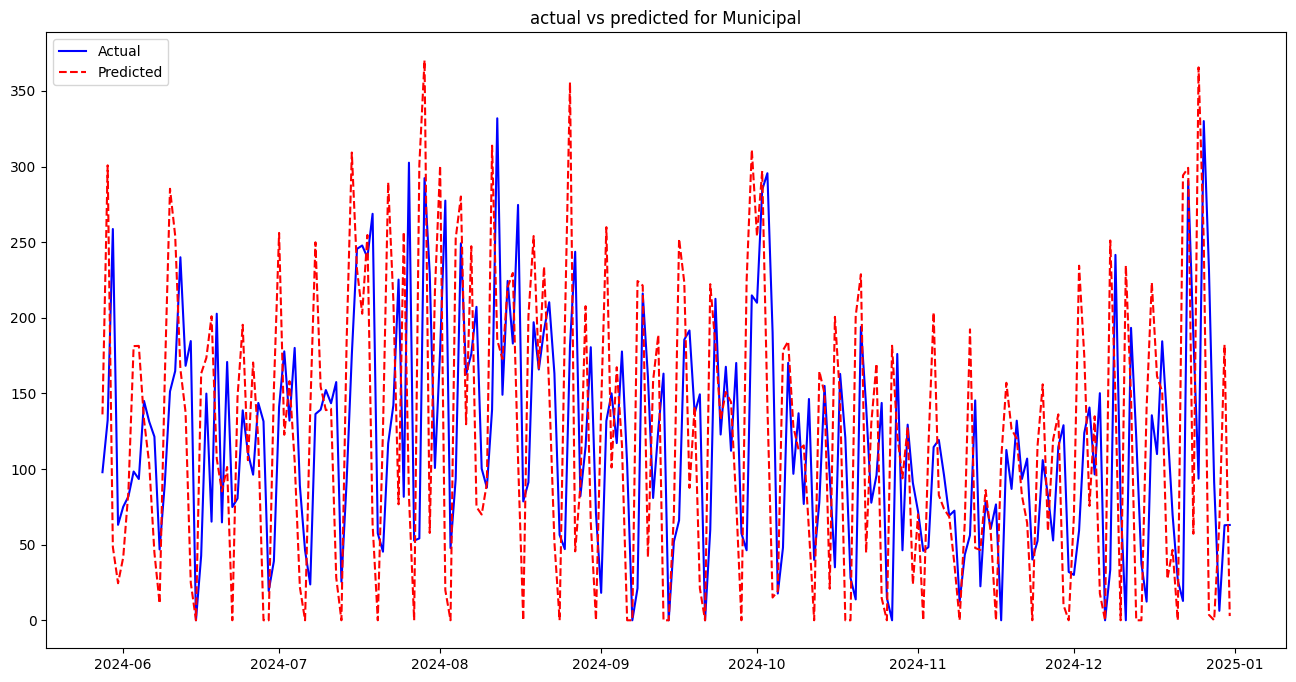

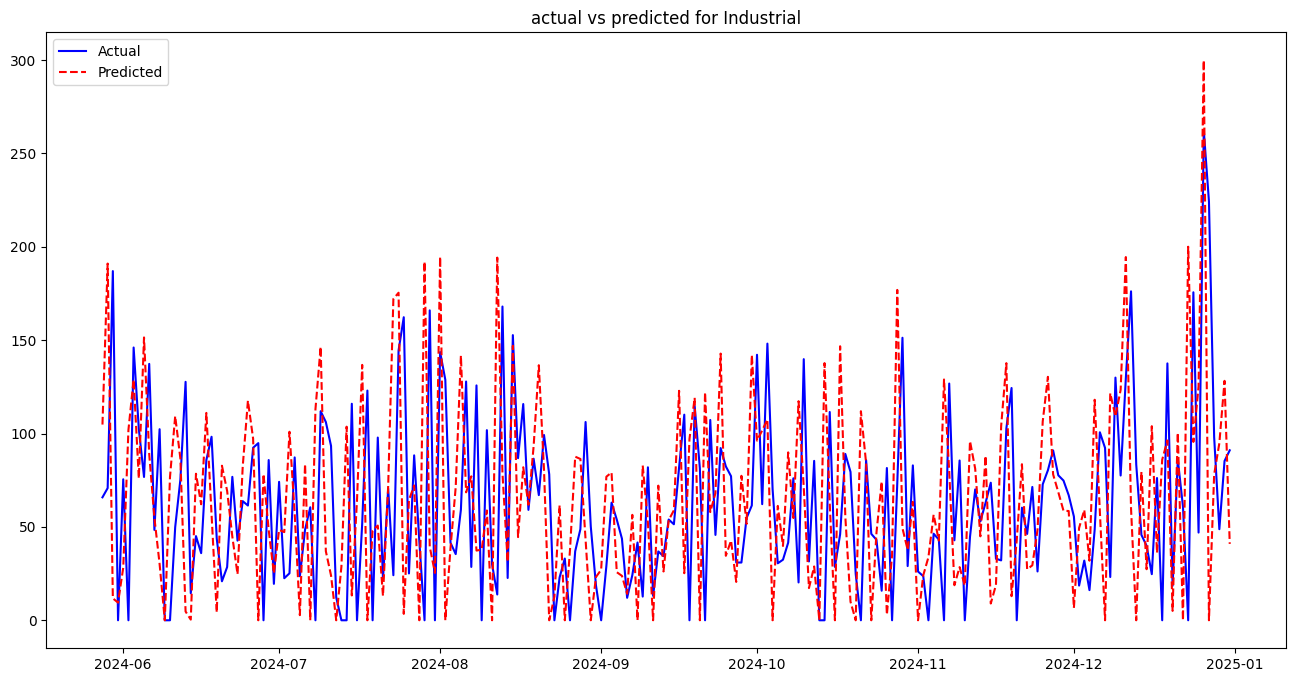

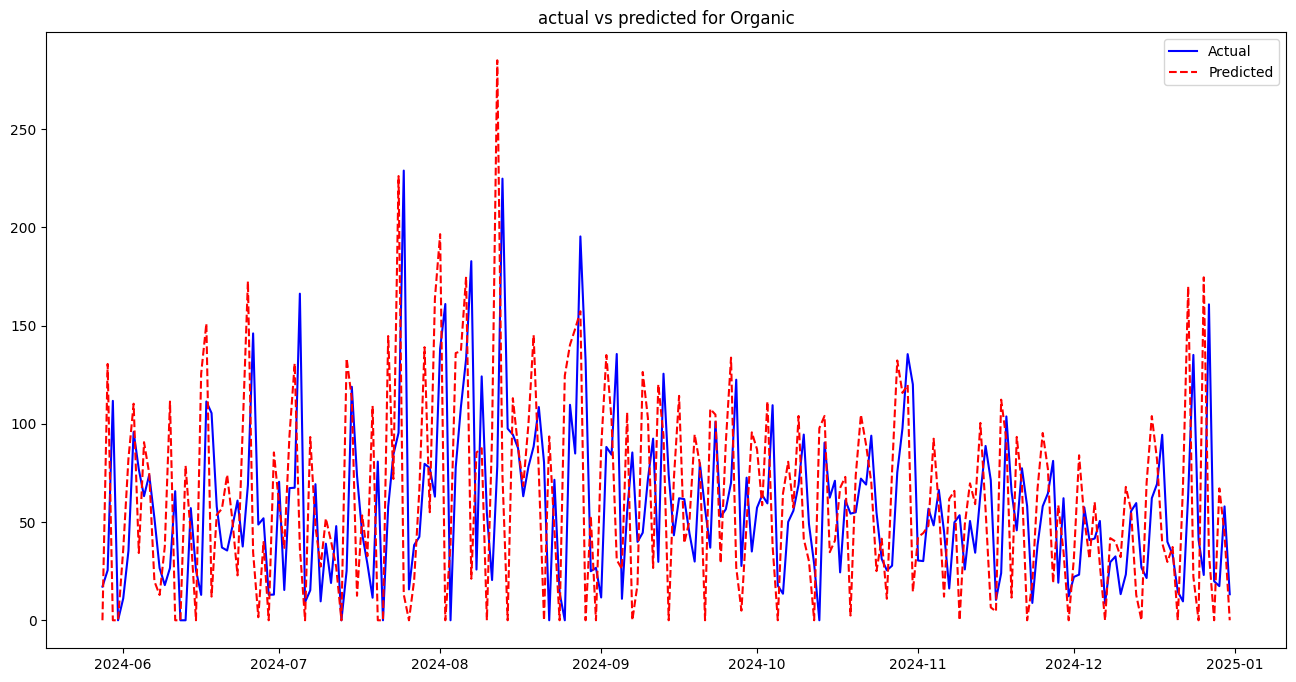

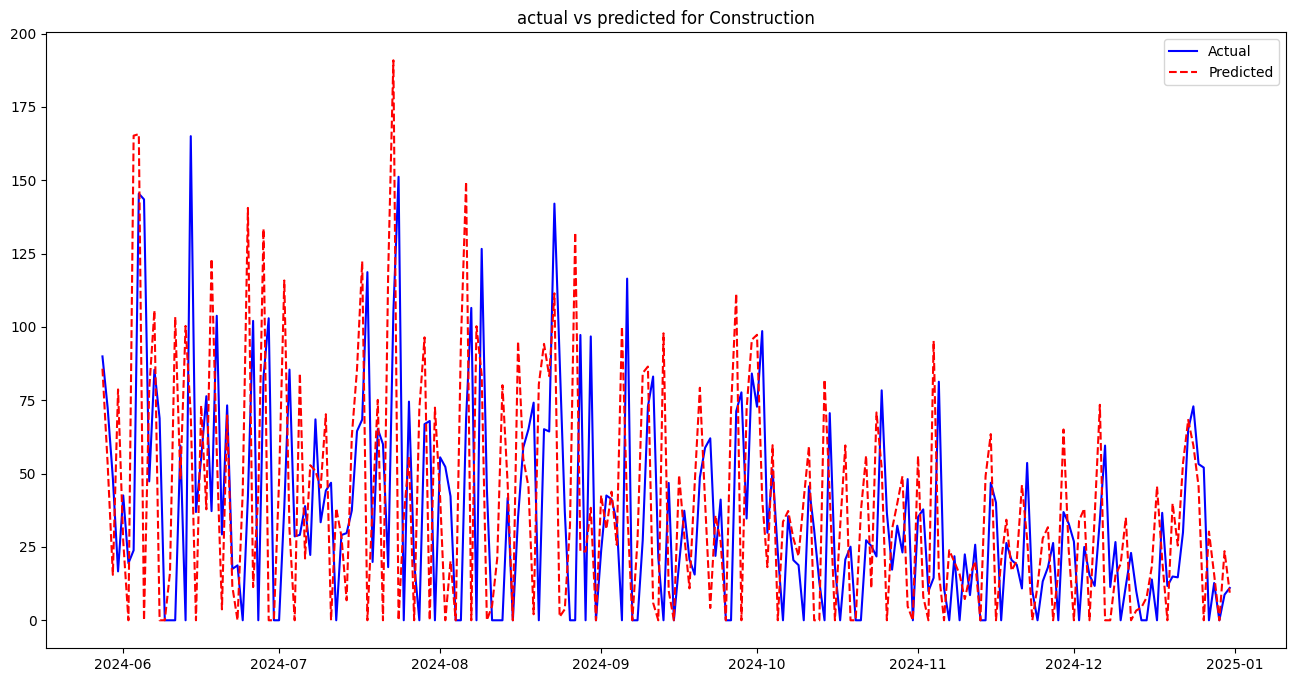

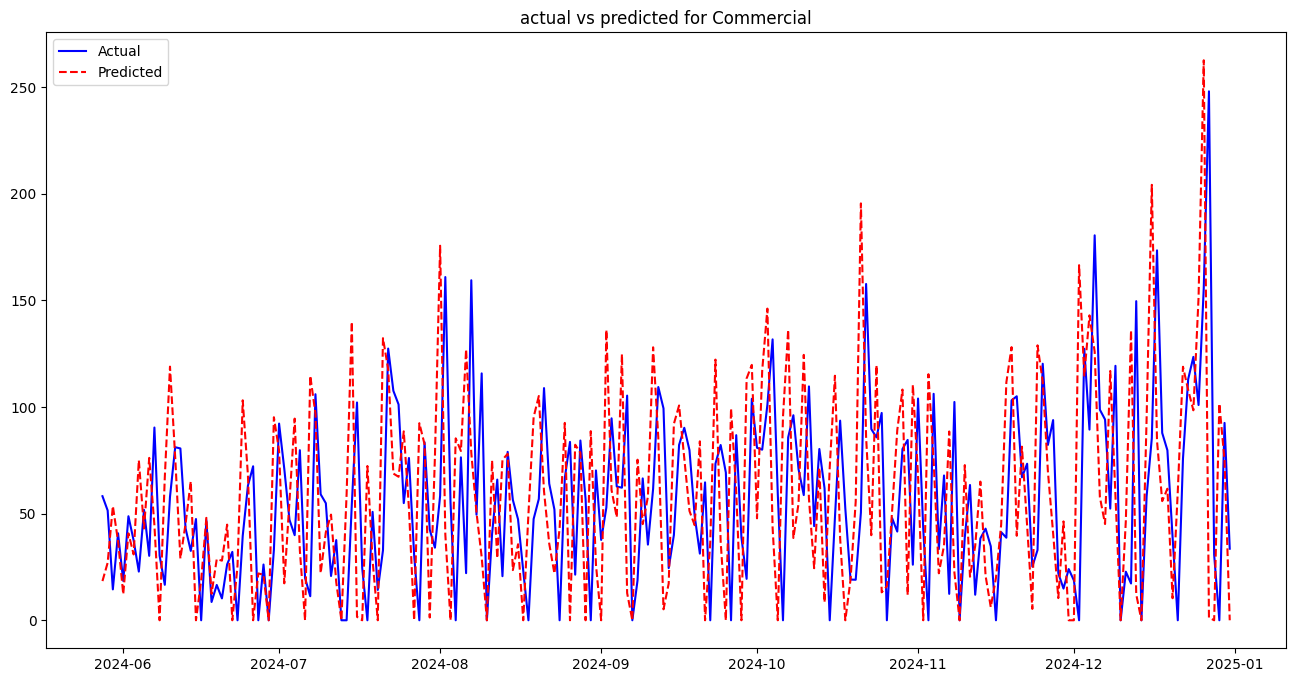

In [89]:
total_actual = np.sum(
    [shifted_waste_dfs[waste]['quantity_tons'].values[split_index+1:] for waste in original_waste_dfs],
    axis=0
)

total_predicted = np.sum(list(waste_quantity_preds.values()), axis=0)

# Convert the predicted differenced values back to the original unit
total_predicted_original = total_predicted + total_actual
total_predicted_original = np.maximum(total_predicted_original,0)

# Calculate RMSE on the original unit
rmse = root_mean_squared_error(total_actual, total_predicted_original)
#print(f"RMSE: {rmse}")

for waste in unique_waste:
    actual_shifted = np.sum(
        [shifted_waste_dfs[waste]['quantity_tons'].values[split_index+1:]],
        axis=0
    )
    actual = np.sum(
        [original_waste_dfs[waste]['quantity_tons'].values[split_index+1:]],
        axis=0
    )
    
    predicted = waste_quantity_preds[waste]
    
    # Convert the predicted differenced values back to the original unit
    predicted_original = predicted + actual_shifted
    predicted_original = np.maximum(predicted_original,0)

    # Calculate RMSE on the original unit
    rmse = root_mean_squared_error(actual, predicted_original)
    rmse = round(rmse,2)

    plt.figure(figsize = (16,8))
    plt.plot(X_test.index[:],actual[:], color = "blue", label='Actual')
    plt.plot(X_test.index[:],predicted_original[:], color = "red", linestyle = "dashed", label = "Predicted")
    plt.title(f"actual vs predicted for {waste}")
    plt.legend()
    print(f"RMSE for {waste}: {rmse}")
    

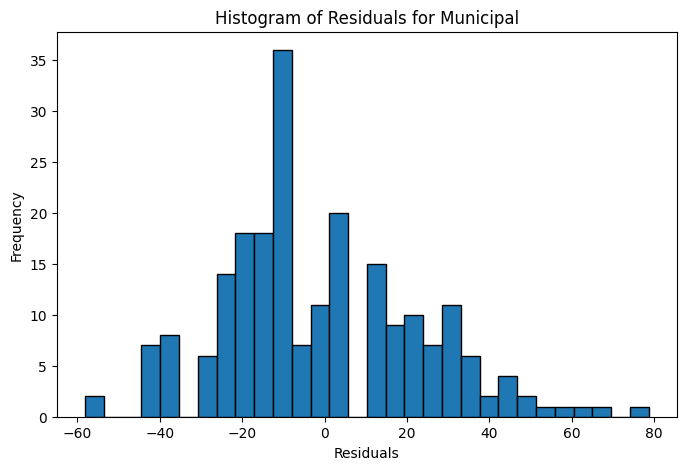

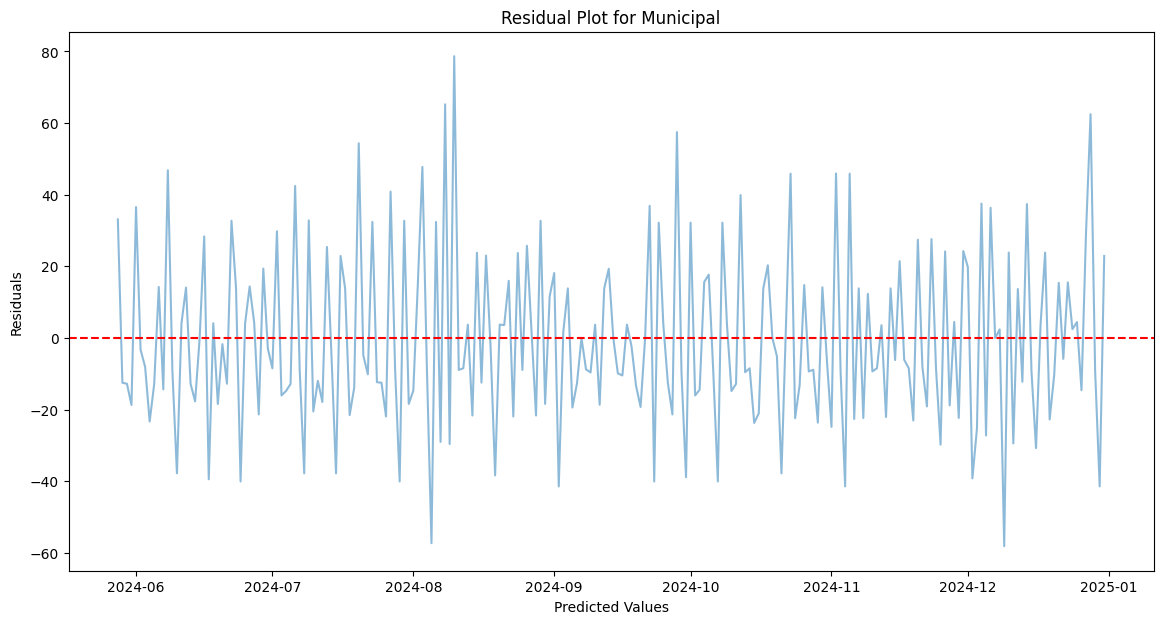

Municipal - Mean Residual: -0.59
Municipal - Standard Deviation: 24.23


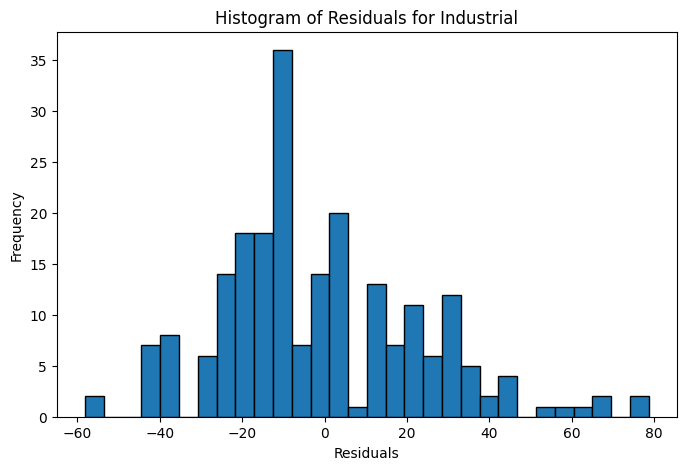

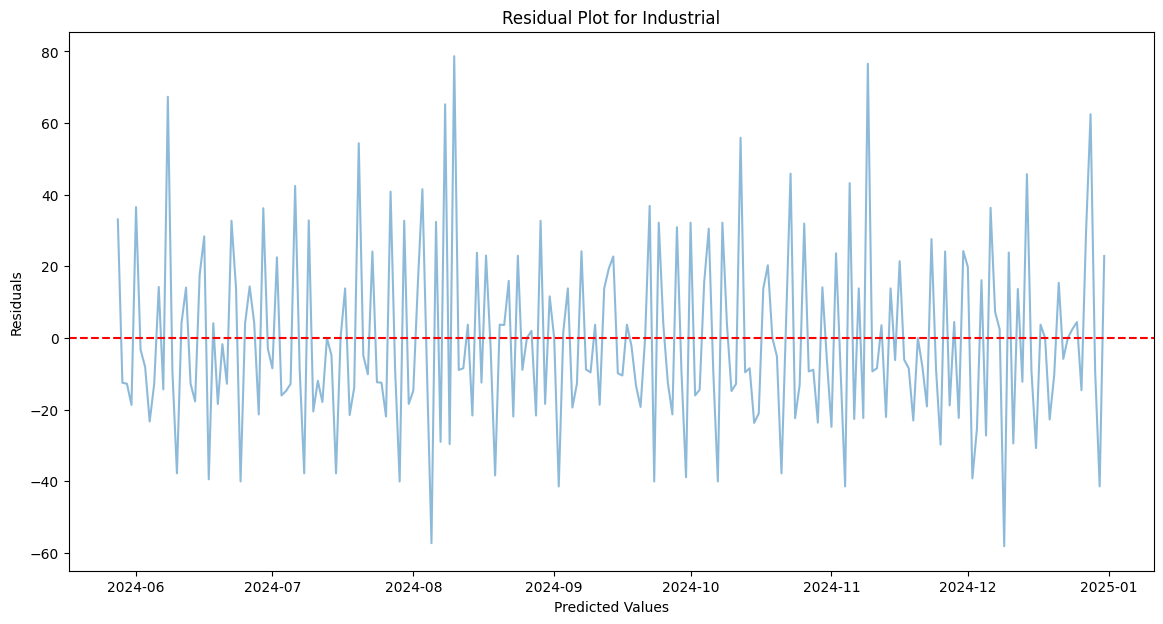

Industrial - Mean Residual: -0.71
Industrial - Standard Deviation: 24.57


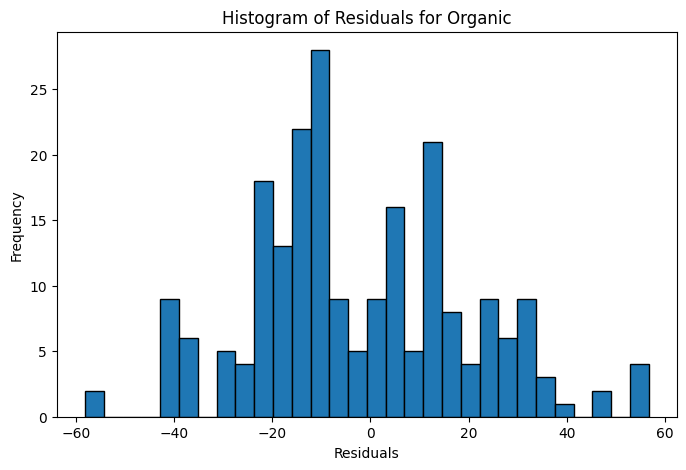

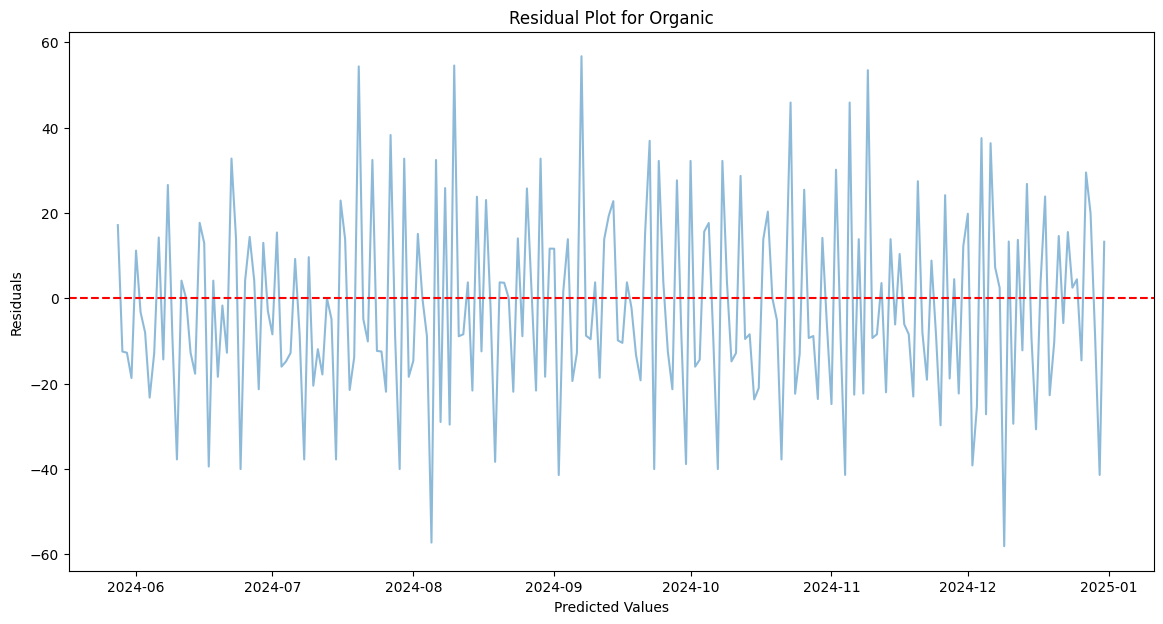

Organic - Mean Residual: -2.16
Organic - Standard Deviation: 21.94


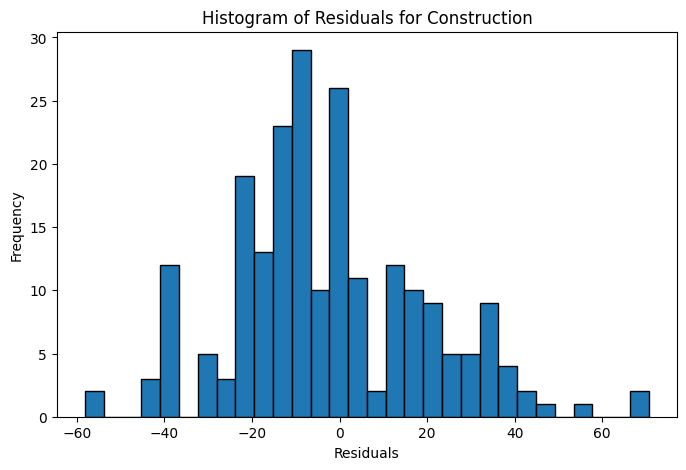

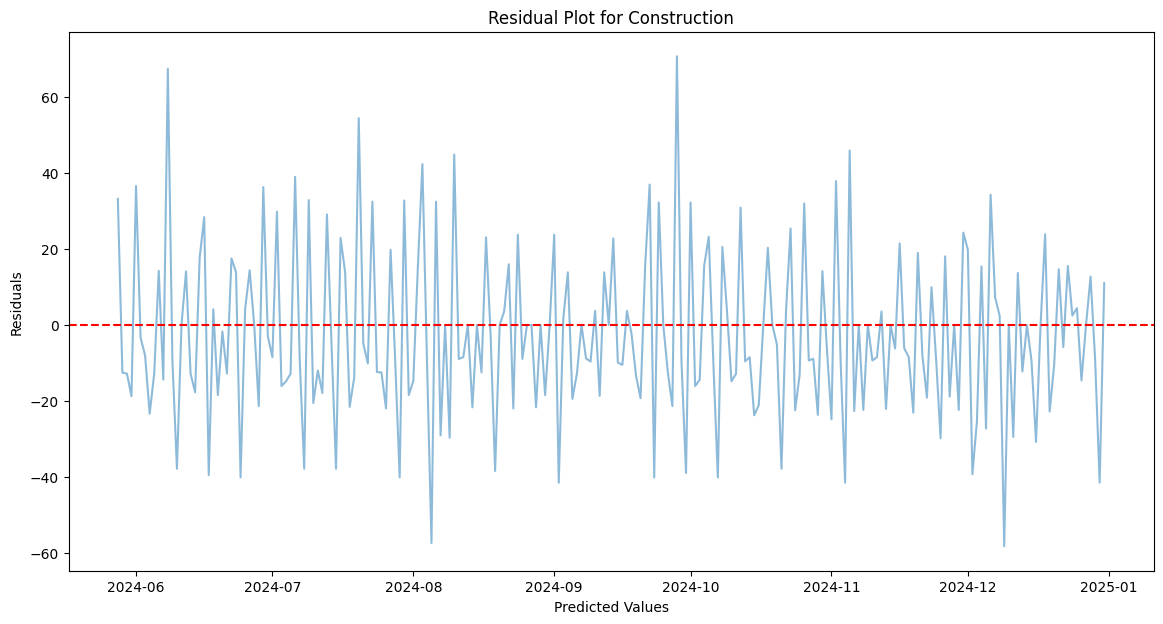

Construction - Mean Residual: -2.68
Construction - Standard Deviation: 22.06


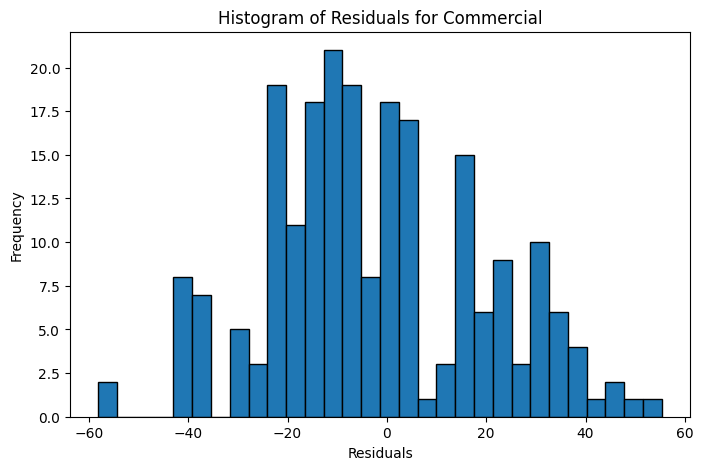

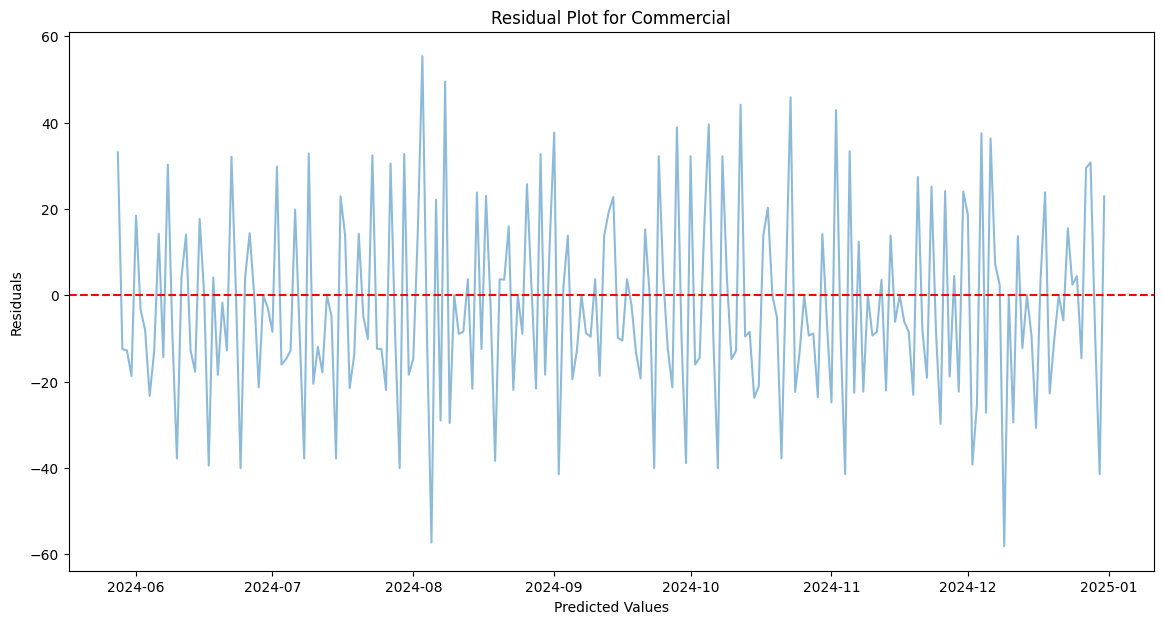

Commercial - Mean Residual: -2.63
Commercial - Standard Deviation: 21.65


In [90]:
# Assuming company_dfs is a dictionary with company names as keys
for waste in original_waste_dfs:
    # Calculate total actual values for the company
    actual_shifted = original_waste_dfs[waste]['quantity_tons'].values[split_index+1:]
    actual = original_waste_dfs[waste]['quantity_tons'].values[split_index+1:]

    # Calculate total predicted values for the company
    total_predicted = waste_quantity_preds[waste]  # Assuming company_quantity_preds is a dict
    

    predicted_original = predicted + actual_shifted
    predicted_original = np.maximum(predicted_original,0)

    # Calculate residuals
    residuals = actual - predicted_original
    time_index = original_waste_dfs[waste].index[split_index+1:]

    # Plot histogram of residuals
    plt.figure(figsize=(8, 5))
    plt.hist(residuals, bins=30, edgecolor="black")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Residuals for {waste}")
    plt.show()

    # Plot residuals against predicted values
    plt.figure(figsize=(14, 7))
    plt.plot(time_index, residuals, alpha=0.5)
    plt.axhline(y=0, color="red", linestyle="--")  # Zero-line for reference
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot for {waste}")
    plt.show()

    # Print mean and standard deviation of residuals
    print(f"{waste} - Mean Residual: {residuals.mean():.2f}")
    print(f"{waste} - Standard Deviation: {residuals.std():.2f}")
